# Baseline: логистическая регрессия:
- загрузка обработанных данных (из `data/processed/`)
- обучение логистической регрессии с `class_weight='balanced'`
- оценка качества на валидационной выборке
- построение ROC-кривой
- сохранение модели и результатов

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
import os

In [2]:
# Создаём папку для графиков этой модели
FIGURES_DIR = '../reports/figures/03_baseline_lr'
os.makedirs(FIGURES_DIR, exist_ok=True)

In [3]:
# 1. Загрузка обработанных данных
X_train = np.load('../data/processed/X_train_scaled.npy')
X_val = np.load('../data/processed/X_val_scaled.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер валидационной выборки: {X_val.shape[0]} строк")
print(f"Доля дефолтов в обучающей выборке: {y_train.mean():.4f}")
print(f"Доля дефолтов в валидационной выборке: {y_val.mean():.4f}")

Размер обучающей выборки: 119773 строк
Размер валидационной выборки: 29944 строк
Доля дефолтов в обучающей выборке: 0.0660
Доля дефолтов в валидационной выборке: 0.0660


In [4]:
# 2. Обучение логистической регрессии
# Параметры: class_weight='balanced' для учёта дисбаланса, random_state для воспроизводимости
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

print("Модель обучена")

Модель обучена


In [5]:
# 3. Предсказание вероятностей и меток
y_pred = lr.predict(X_val)
y_pred_proba = lr.predict_proba(X_val)[:, 1]

In [6]:
# 4. Оценка качества
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_proba)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Precision: 0.2564
Recall:    0.6194
F1-score:  0.3627
ROC-AUC:   0.8165


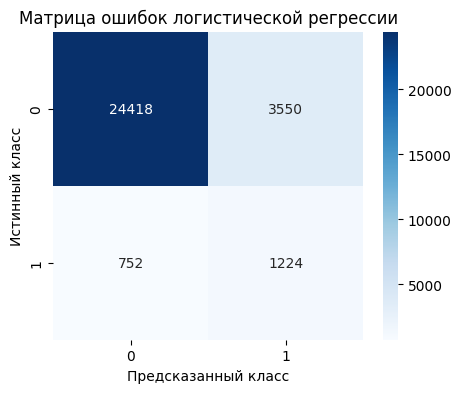

In [7]:
# 5. Матрица ошибок (confusion matrix)
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок логистической регрессии')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.savefig(os.path.join(FIGURES_DIR, 'confusion_matrix.png'), bbox_inches='tight')
plt.show()

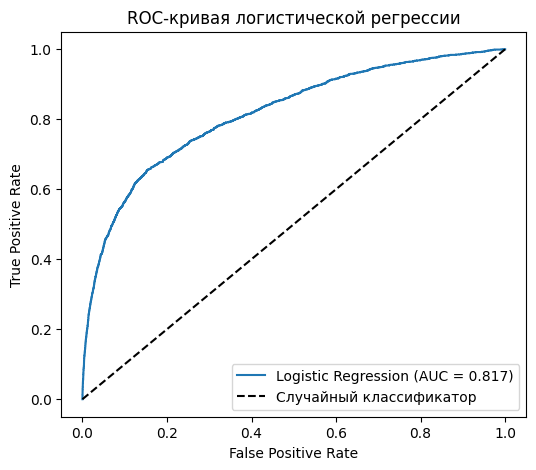

In [8]:
# 6. ROC-кривая
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая логистической регрессии')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'roc_curve.png'), bbox_inches='tight')
plt.show()

In [9]:
# 7. Сохранение модели и результатов
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# Сохраняем модель
with open(os.path.join(model_dir, 'logistic_regression.pkl'), 'wb') as f:
    pickle.dump(lr, f)

# Сохраняем метрики в текстовый файл (опционально)
with open(os.path.join(FIGURES_DIR, 'metrics.txt'), 'w') as f:
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-score:  {f1:.4f}\n")
    f.write(f"ROC-AUC:   {roc_auc:.4f}\n")

print("Модель и метрики сохранены")

Модель и метрики сохранены


In [10]:
# 8. Дополнительно: classification report (для справки)
print("\nClassification report:")
print(classification_report(y_val, y_pred, target_names=['Non-default', 'Default']))


Classification report:
              precision    recall  f1-score   support

 Non-default       0.97      0.87      0.92     27968
     Default       0.26      0.62      0.36      1976

    accuracy                           0.86     29944
   macro avg       0.61      0.75      0.64     29944
weighted avg       0.92      0.86      0.88     29944

